# Business Analysis Project - Assignment 06

### Import Supportive/Required Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Global chart style
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})

COLORS = ['#1a6faf','#e06c00','#2ca02c','#d62728','#9467bd',
          '#8c564b','#e377c2','#17becf','#bcbd22','#7f7f7f']
BLUE, ORANGE, GREEN, RED = '#1a6faf', '#e06c00', '#2ca02c', '#d62728'


#### Loading Datasets, Descriptive Analysis & Data Cleaning:
    - customers.xlsx
    - products.xlsx
    - customer_reviews.xlsx
    - engagement_data.xlsx
    - customer_journey.xlsx
    - geography.xlsx

In [10]:
customers = pd.read_excel(r"G:\Jupyter Notebook\Practice Data Files\customers.xlsx")

products = pd.read_excel(r"G:\Jupyter Notebook\Practice Data Files\products.xlsx")

customer_reviews = pd.read_excel(r"G:\Jupyter Notebook\Practice Data Files\customer_reviews.xlsx")

engagement_data = pd.read_excel(r"G:\Jupyter Notebook\Practice Data Files\engagement_data.xlsx")

customer_journey = pd.read_excel(r"G:\Jupyter Notebook\Practice Data Files\customer_journey.xlsx")

geography = pd.read_excel(r"G:\Jupyter Notebook\Practice Data Files\geography.xlsx")


In [11]:
customers.shape

(100, 6)

In [12]:
products.shape

(20, 4)

In [13]:
customer_reviews.shape

(1363, 6)

In [14]:
engagement_data.shape

(4623, 8)

In [15]:
customer_journey.shape

(4011, 7)

In [16]:
geography.shape

(10, 3)

In [17]:
engagement_data['ViewsClickCombined'] = engagement_data['ViewsClickCombined'].astype(str)
split = engagement_data['ViewsClickCombined'].str.split('-', expand=True)
engagement_data['Views']  = pd.to_numeric(split[0], errors='coerce').fillna(0).astype(int)
engagement_data['Clicks'] = pd.to_numeric(split[1], errors='coerce').fillna(0).astype(int)


In [18]:
customers.head()

,CustomerID,CustomerName,Email,Gender,Age,GeographyID
0,1,Emma Anderson,emma.anderson@example.com,Male,50,2
1,2,Sarah Brown,sarah.brown@example.com,Female,37,4
2,3,Robert Hernandez,robert.hernandez@example.com,Female,26,6
3,4,David Garcia,david.garcia@example.com,Male,25,8
4,5,Emma Miller,emma.miller@example.com,Female,41,4


In [19]:
customer_reviews.head()

,ReviewID,CustomerID,ProductID,ReviewDate,Rating,ReviewText
0,1,77,18,2023-12-23,3,"Average experience, nothing special."
1,2,80,19,2024-12-25,5,The quality is top-notch.
2,3,50,13,2025-01-26,4,Five stars for the quick delivery.
3,4,78,15,2025-04-21,3,"Good quality, but could be cheaper."
4,5,64,2,2023-07-16,3,"Average experience, nothing special."


In [20]:
engagement_data.head()

,EngagementID,ContentID,ContentType,Likes,EngagementDate,CompaignID,ProductID,ViewsClickCombined,Views,Clicks
0,1,39,Blog,190,2023-08-30,1,9,1883-671,1883,671
1,2,48,Blog,114,2023-03-28,18,20,5280-532,5280,532
2,3,16,video,32,2023-12-08,7,14,1905-204,1905,204
3,4,43,Video,17,2025-01-21,19,20,2766-257,2766,257
4,5,16,newsletter,306,2024-02-21,6,15,5116-1524,5116,1524


In [21]:
products.head()

,ProductID,ProductName,Category,Price
0,1,Running Shoes,Sports,223.75
1,2,Fitness Tracker,Sports,196.68
2,3,Yoga Mat,Sports,485.32
3,4,Dumbbells,Sports,26.21
4,5,Soccer Ball,Sports,41.26


In [22]:
customer_journey.head()

,JourneyID,CustomerID,ProductId,VisitDate,Stage,Action,Duration
0,1,64,18,2024-06-10,Checkout,Drop-off,NaN
1,2,94,11,2025-07-09,Checkout,Drop-off,NaN
2,3,34,8,2024-06-14,ProductPage,View,235.0
3,4,33,18,2025-05-28,Checkout,Drop-off,NaN
4,5,91,10,2023-02-11,Homepage,Click,156.0


In [23]:
geography.head()

,ID,Region,City
0,1,UK,London
1,2,Germany,Berlin
2,3,France,Paris
3,4,Spain,Madrid
4,5,Italy,Rome


In [25]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   CustomerID    100 non-null    int64 
 1   CustomerName  100 non-null    object
 2   Email         100 non-null    object
 3   Gender        100 non-null    object
 4   Age           100 non-null    int64 
 5   GeographyID   100 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 4.8+ KB


In [26]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ProductID    20 non-null     int64  
 1   ProductName  20 non-null     object 
 2   Category     20 non-null     object 
 3   Price        20 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 772.0+ bytes


In [27]:
customer_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1363 entries, 0 to 1362
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ReviewID    1363 non-null   int64         
 1   CustomerID  1363 non-null   int64         
 2   ProductID   1363 non-null   int64         
 3   ReviewDate  1363 non-null   datetime64[ns]
 4   Rating      1363 non-null   int64         
 5   ReviewText  1363 non-null   object        
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 64.0+ KB


In [28]:
engagement_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4623 entries, 0 to 4622
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   EngagementID        4623 non-null   int64         
 1   ContentID           4623 non-null   int64         
 2   ContentType         4623 non-null   object        
 3   Likes               4623 non-null   int64         
 4   EngagementDate      4623 non-null   datetime64[ns]
 5   CompaignID          4623 non-null   int64         
 6   ProductID           4623 non-null   int64         
 7   ViewsClickCombined  4623 non-null   object        
 8   Views               4623 non-null   int64         
 9   Clicks              4623 non-null   int64         
dtypes: datetime64[ns](1), int64(7), object(2)
memory usage: 361.3+ KB


In [29]:
customer_journey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4011 entries, 0 to 4010
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   JourneyID   4011 non-null   int64         
 1   CustomerID  4011 non-null   int64         
 2   ProductId   4011 non-null   int64         
 3   VisitDate   4011 non-null   datetime64[ns]
 4   Stage       4011 non-null   object        
 5   Action      4011 non-null   object        
 6   Duration    3398 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 219.5+ KB


In [30]:
geography.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      10 non-null     int64 
 1   Region  10 non-null     object
 2   City    10 non-null     object
dtypes: int64(1), object(2)
memory usage: 372.0+ bytes


In [31]:
customer_journey.isnull().sum()

JourneyID       0
CustomerID      0
ProductId       0
VisitDate       0
Stage           0
Action          0
Duration      613
dtype: int64

In [32]:
products.isnull().sum()

ProductID      0
ProductName    0
Category       0
Price          0
dtype: int64

In [33]:
customer_reviews.isnull().sum()

ReviewID      0
CustomerID    0
ProductID     0
ReviewDate    0
Rating        0
ReviewText    0
dtype: int64

In [34]:
engagement_data.isnull().sum()

EngagementID          0
ContentID             0
ContentType           0
Likes                 0
EngagementDate        0
CompaignID            0
ProductID             0
ViewsClickCombined    0
Views                 0
Clicks                0
dtype: int64

In [35]:
customer_journey.isnull().sum()

JourneyID       0
CustomerID      0
ProductId       0
VisitDate       0
Stage           0
Action          0
Duration      613
dtype: int64

In [36]:
geography.isnull().sum()

ID        0
Region    0
City      0
dtype: int64

In [37]:
customers.describe()

,CustomerID,Age,GeographyID
count,100.000000,100.000000,100.000000
mean,50.500000,41.990000,5.320000
std,29.011492,14.259142,2.810083
min,1.000000,18.000000,1.000000
25%,25.750000,31.000000,3.000000
50%,50.500000,41.000000,5.000000
75%,75.250000,53.000000,8.000000
max,100.000000,69.000000,10.000000


In [38]:
products.describe()

,ProductID,Price
count,20.00000,20.000000
mean,10.50000,205.405500
std,5.91608,149.461816
min,1.00000,26.210000
25%,5.75000,44.262500
50%,10.50000,210.215000
75%,15.25000,288.412500
max,20.00000,485.320000


In [39]:
customer_reviews.describe()

,ReviewID,CustomerID,ProductID,ReviewDate,Rating
count,1363.00000,1363.000000,1363.000000,1363,1363.000000
mean,682.00000,51.701394,10.337491,2024-07-08 06:01:19.236977408,3.686720
min,1.00000,1.000000,1.000000,2023-01-01 00:00:00,1.000000
25%,341.50000,27.000000,5.000000,2023-10-09 00:00:00,3.000000
50%,682.00000,53.000000,10.000000,2024-07-08 00:00:00,4.000000
75%,1022.50000,77.000000,15.000000,2025-04-16 00:00:00,5.000000
max,1363.00000,100.000000,20.000000,2025-12-31 00:00:00,5.000000
std,393.60852,28.605493,5.702922,NaN,1.180243


In [52]:
engagement_data.describe()

,EngagementID,ContentID,Likes,EngagementDate,CompaignID,ProductID,Views,Clicks
count,4623.000000,4623.000000,4623.000000,4623,4623.000000,4623.000000,4623.00000,4623.000000
mean,2312.000000,25.426130,114.368592,2024-07-10 07:55:00.973393920,10.660826,10.424616,2545.65650,497.940947
min,1.000000,1.000000,0.000000,2023-01-01 00:00:00,1.000000,1.000000,13.00000,0.000000
25%,1156.500000,13.000000,3.000000,2023-10-12 00:00:00,6.000000,5.000000,781.00000,50.000000
50%,2312.000000,25.000000,28.000000,2024-07-13 00:00:00,11.000000,10.000000,1889.00000,229.000000
75%,3467.500000,38.000000,131.000000,2025-04-09 00:00:00,16.000000,15.000000,3881.50000,685.500000
max,4623.000000,50.000000,1977.000000,2025-12-31 00:00:00,20.000000,20.000000,9759.00000,4574.000000
std,1334.689477,14.292613,205.083859,NaN,5.770570,5.795959,2188.29329,667.400293


In [54]:
customer_journey.describe()

,JourneyID,CustomerID,ProductId,VisitDate,Duration
count,4011.000000,4011.000000,4011.000000,4011,3398.000000
mean,1973.453752,53.096734,10.460234,2024-06-17 09:41:57.576664320,156.513243
min,1.000000,1.000000,1.000000,2023-01-01 00:00:00,10.000000
25%,986.500000,29.000000,5.000000,2023-09-04 12:00:00,86.000000
50%,1977.000000,54.000000,10.000000,2024-06-14 00:00:00,157.000000
75%,2958.500000,78.000000,16.000000,2025-03-27 00:00:00,228.000000
max,3932.000000,100.000000,20.000000,2025-12-30 00:00:00,300.000000
std,1137.158463,28.347921,5.844588,NaN,83.213779


In [55]:
geography.describe()

,ID
count,10.00000
mean,5.50000
std,3.02765
min,1.00000
25%,3.25000
50%,5.50000
75%,7.75000
max,10.00000


In [11]:
engagement_data['ContentType'] = engagement_data['ContentType'].str.strip().str.title()

In [12]:
customer_journey['Stage']  = customer_journey['Stage'].str.strip().str.title()
customer_journey['Action'] = customer_journey['Action'].str.strip().str.title()

In [13]:
def age_category(age):
    if age < 30:   return 'Young'
    elif age < 55: return 'Adult'
    else:          return 'Senior'
customers['AgeCategory'] = customers['Age'].apply(age_category)

In [14]:
cust_geo = customers.merge(geography, left_on='GeographyID', right_on='ID', how='left')

In [15]:
master = customer_reviews.merge(
    cust_geo[['CustomerID','CustomerName','Gender','Age','AgeCategory','Region','City']],
    on='CustomerID', how='left')
master = master.merge(products, on='ProductID', how='left')

In [16]:
eng = engagement_data.merge(products, on='ProductID', how='left')
eng['EngagementRate'] = ((eng['Clicks'] + eng['Likes']) / eng['Views'] * 100).round(2)

In [17]:
journey = customer_journey.merge(products, left_on='ProductId', right_on='ProductID', how='left')
journey = journey.merge(
    cust_geo[['CustomerID','Gender','Age','AgeCategory','Region']],
    on='CustomerID', how='left')

## Part 1 - Customer Analysis

In [19]:
# 01__Total kitne unique customers hain?

In [20]:
total_customers = customers['CustomerID'].nunique()
print(f'Total unique customers: {total_customers}')

Total unique customers: 100


In [21]:
# 02__Age category (Young, Adult, Senior) ke hisaab se customers ki distribution dikhayein.

Customer count by age category:
AgeCategory
Young     24
Adult     54
Senior    22


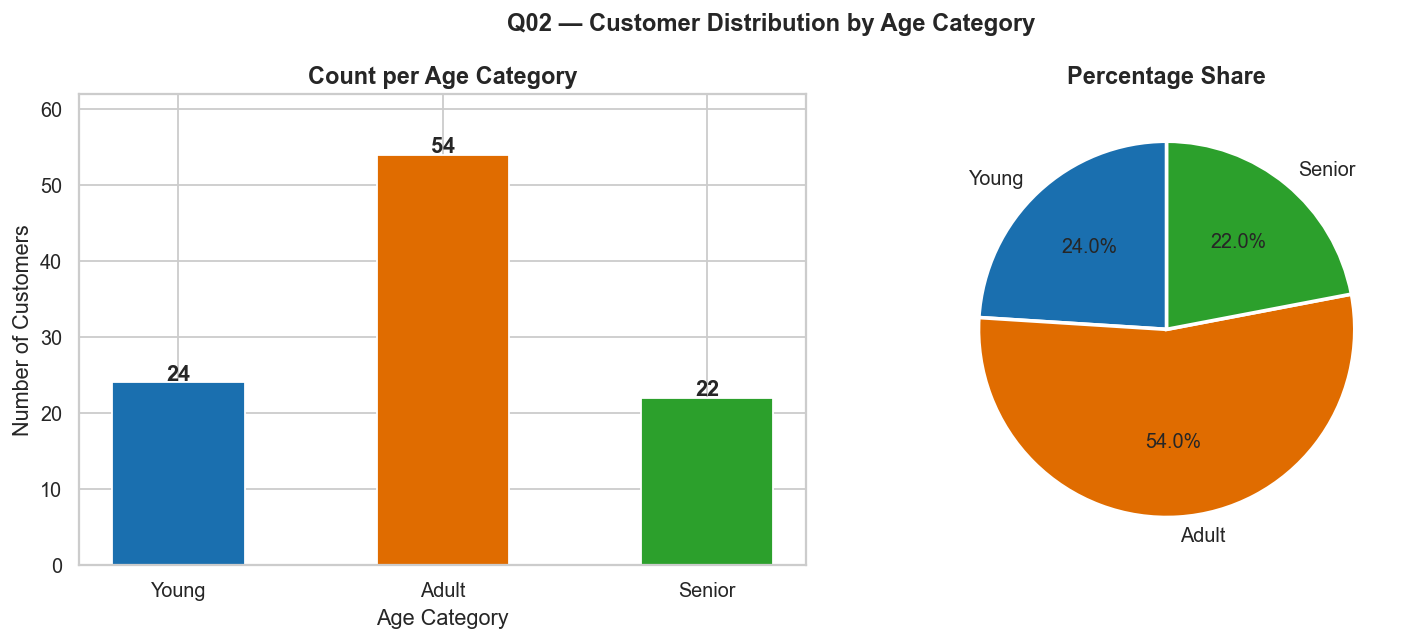

In [22]:
age_dist = (customers['AgeCategory']
            .value_counts()
            .reindex(['Young','Adult','Senior'])
            .fillna(0).astype(int))

print('Customer count by age category:')
print(age_dist.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Q02 — Customer Distribution by Age Category', fontweight='bold')

bars = axes[0].bar(age_dist.index, age_dist.values,
                   color=[BLUE, ORANGE, GREEN], edgecolor='white', width=0.5)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 str(int(bar.get_height())), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Count per Age Category')
axes[0].set_xlabel('Age Category')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, age_dist.max() + 8)

pie = age_dist[age_dist > 0]
axes[1].pie(pie.values, labels=pie.index,
            colors=[BLUE, ORANGE, GREEN][:len(pie)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Percentage Share')

plt.tight_layout()
plt.show()


In [23]:
# 03__Gender ke hisaab se total customers kitne hain?

In [26]:
gender_count = customers['Gender'].value_counts()
print('Unique customers by gender:')
print(gender_count.to_string())


Unique customers by gender:
Gender
Female    54
Male      46


In [27]:
avg_rating_age = (master.groupby('AgeCategory')['Rating']
                         .mean()
                         .reindex(['Young','Adult','Senior'])
                         .round(2))

print('Average review rating by age category:')
print(avg_rating_age.to_string())


Average review rating by age category:
AgeCategory
Young     3.66
Adult     3.71
Senior    3.66


In [28]:
# 05__Har gender ki average purchase value calculate karein.

In [29]:
purchases = journey[journey['Action'] == 'Purchase']
avg_purchase_gender = purchases.groupby('Gender')['Price'].mean().round(2)
print('Average purchase value by gender:')
print(avg_purchase_gender.to_string())


Average purchase value by gender:
Gender
Female    220.63
Male      217.96


In [32]:
# 06__Kis country mein sabse zyada customers hain?

In [34]:
country_dist = (cust_geo.groupby('Region')['CustomerID']
                 .count().sort_values(ascending=False))

print(f' Highest: {country_dist.idxmax()} ({country_dist.max()} customers)')


 Highest: Spain (18 customers)


In [35]:
# 07__Har country ki average review rating calculate karein.

In [36]:
avg_rating_region = (master.groupby('Region')['Rating']
                            .mean().round(2)
                            .sort_values(ascending=False))
print('Average review rating by region:')
print(avg_rating_region.to_string())


Average review rating by region:
Region
Spain          3.77
France         3.75
Germany        3.74
UK             3.72
Netherlands    3.69
Sweden         3.69
Italy          3.68
Austria        3.65
Belgium        3.58
Switzerland    3.49


In [37]:
# 08__Har country ka average engagement score nikaalein.

In [38]:
journey_eng = journey.merge(
    eng[['ProductID','Views','Clicks','Likes','EngagementRate']]
    .groupby('ProductID').mean().round(2).reset_index(),
    on='ProductID', how='left')

avg_eng_region = (journey_eng.groupby('Region')['EngagementRate']
                              .mean().round(2)
                              .sort_values(ascending=False))
print('Average engagement rate by region:')
print(avg_eng_region.to_string())


Average engagement rate by region:
Region
Germany        17.81
Italy          17.79
Switzerland    17.77
Austria        17.76
Spain          17.76
France         17.73
UK             17.71
Netherlands    17.69
Belgium        17.68
Sweden         17.63


In [39]:
# 09__Kis age group ki engagement sabse zyada hai?

In [41]:
journey_eng2 = journey.merge(
    eng[['ProductID','EngagementRate']].groupby('ProductID').mean().round(2).reset_index(),
    on='ProductID', how='left')

avg_eng_age = (journey_eng2.groupby('AgeCategory')['EngagementRate']
                            .mean()
                            .reindex(['Young','Adult','Senior'])
                            .round(2))

print(f' Highest engagement: {avg_eng_age.idxmax()} ({avg_eng_age.max():.2f}%)')


 Highest engagement: Young (17.76%)


In [42]:
# 10__Kya male aur female customers ki average ratings mein koi difference hai? Graph ke saath explain karein.

Average review rating by gender:
Gender
Female    3.65
Male      3.73

Difference: 0.0800 — Very small / negligible difference


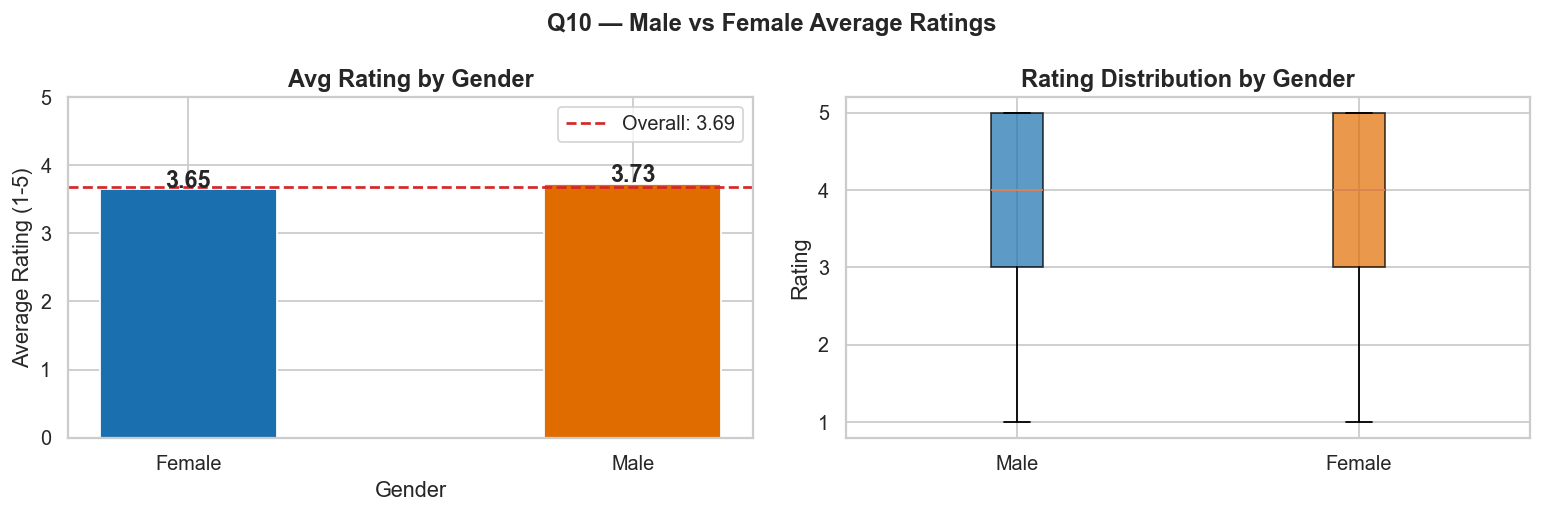

In [43]:
avg_rating_gender = master.groupby('Gender')['Rating'].mean().round(2)
print('Average review rating by gender:')
print(avg_rating_gender.to_string())
diff = abs(avg_rating_gender.diff().dropna().values[0])
print(f'\nDifference: {diff:.4f} — {"Notable" if diff > 0.1 else "Very small / negligible"} difference')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Q10 — Male vs Female Average Ratings', fontweight='bold')

bars = axes[0].bar(avg_rating_gender.index, avg_rating_gender.values,
                   color=[BLUE, ORANGE], edgecolor='white', width=0.4)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{bar.get_height():.2f}', ha='center', fontweight='bold', fontsize=13)
axes[0].axhline(master['Rating'].mean(), color=RED, linestyle='--',
                label=f'Overall: {master["Rating"].mean():.2f}')
axes[0].set_title('Avg Rating by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Average Rating (1-5)')
axes[0].set_ylim(0, 5)
axes[0].legend()

male_ratings   = master[master['Gender']=='Male']['Rating']
female_ratings = master[master['Gender']=='Female']['Rating']
bp = axes[1].boxplot([male_ratings, female_ratings],
                     labels=['Male','Female'], patch_artist=True)
for patch, color in zip(bp['boxes'], [BLUE, ORANGE]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('Rating Distribution by Gender')
axes[1].set_ylabel('Rating')
plt.tight_layout()
plt.show()


## Part 2 - Product Analysis

In [44]:
# 11__Sabse zyada purchase hone wale Top 10 products dikhayein.

In [45]:
purchases = journey[journey['Action'] == 'Purchase']
top10_selling = (purchases.groupby('ProductName')['JourneyID']
                           .count().sort_values(ascending=False).head(10))
top10_selling.name = 'Total Purchases'
print('Top 10 highest selling products:')
print(top10_selling.to_string())


Top 10 highest selling products:
ProductName
Hockey Stick       15
Baseball Glove     13
Ski Boots          13
Ice Skates         13
Cycling Helmet     12
Climbing Rope      12
Surfboard          12
Fitness Tracker    11
Golf Clubs         10
Kayak              10


In [46]:
# 12__Sabse zyada reviews kis products ko mile hain?

In [51]:
review_count = (customer_reviews.merge(products, on='ProductID')
                .groupby('ProductName')['ReviewID'].count()
                .sort_values(ascending=False))
review_avg = (customer_reviews.merge(products, on='ProductID')
              .groupby('ProductName')['Rating'].mean().round(2))

review_summary = pd.DataFrame({'ReviewCount': review_count, 'AvgRating': review_avg})

print('Products by review count and average rating:')

print(f' Most reviewed   : {review_count.idxmax()} ({review_count.max()} reviews)')


Products by review count and average rating:
 Most reviewed   : Ice Skates (79 reviews)


In [52]:
# 13__Sabse zyada engagement wale Top 10 products identify karein.

In [53]:
top10_eng = (eng.groupby('ProductName')['EngagementRate']
                 .mean().round(2)
                 .sort_values(ascending=False).head(10))
print('Top 10 products by avg engagement rate:')
print(top10_eng.to_string())


Top 10 products by avg engagement rate:
ProductName
Running Shoes      19.36
Football Helmet    18.91
Yoga Mat           18.90
Boxing Gloves      18.45
Swim Goggles       18.31
Baseball Glove     18.28
Ice Skates         18.17
Golf Clubs         17.96
Hockey Stick       17.96
Soccer Ball        17.89


In [54]:
# 14__Har product category ki average rating calculate karein.

In [55]:
avg_rating_cat = (master.groupby('Category')['Rating']
                         .mean().round(2)
                         .sort_values(ascending=False))
print('Average rating by product category:')
print(avg_rating_cat.to_string())


Average rating by product category:
Category
Sports    3.69


In [56]:
# 15__Har category ki average engagement calculate karein.

In [57]:
avg_eng_cat = (eng.groupby('Category')['EngagementRate']
                  .mean().round(2).sort_values(ascending=False))
print('Average engagement rate by category:')
print(avg_eng_cat.to_string())


Average engagement rate by category:
Category
Sports    17.73


In [58]:
# 16__Har category ki average views aur clicks compare karein.

In [62]:
views_clicks_cat = eng.groupby('Category').agg(
    Avg_Views  = ('Views',  'mean'),
    Avg_Clicks = ('Clicks', 'mean')
).round(0).astype(int)
print('Avg Views vs Clicks by category:')
print(views_clicks_cat.to_string())


Avg Views vs Clicks by category:
          Avg_Views  Avg_Clicks
Category                       
Sports         2546         498


In [60]:
# 17__Lowest rated Top 10 products kaun se hain?

In [61]:
bottom10_rated = (master.groupby('ProductName')['Rating']
                         .mean().round(2)
                         .sort_values(ascending=True).head(10))
print('Bottom 10 products by lowest average rating:')
print(bottom10_rated.to_string())


Bottom 10 products by lowest average rating:
ProductName
Golf Clubs       3.48
Yoga Mat         3.52
Tennis Racket    3.56
Running Shoes    3.57
Volleyball       3.58
Boxing Gloves    3.61
Dumbbells        3.63
Surfboard        3.65
Soccer Ball      3.67
Hockey Stick     3.67


In [63]:
# 18__Highest rated Top 10 products kaun se hain?

In [64]:
top10_rated = (master.groupby('ProductName')['Rating']
                      .mean().round(2)
                      .sort_values(ascending=False).head(10))
print('Top 10 products by highest average rating:')
print(top10_rated.to_string())


Top 10 products by highest average rating:
ProductName
Climbing Rope      3.91
Swim Goggles       3.84
Cycling Helmet     3.80
Kayak              3.79
Basketball         3.78
Fitness Tracker    3.78
Baseball Glove     3.73
Ski Boots          3.73
Ice Skates         3.70
Football Helmet    3.70


In [65]:
# 19__Kis category mein views zyada hain lekin purchases kam hain?

In [66]:
views_by_cat = eng.groupby('Category')['Views'].sum()
purchases_by_cat = journey[journey['Action']=='Purchase'].groupby('Category')['JourneyID'].count()

cat_compare = pd.DataFrame({
    'Total_Views'     : views_by_cat,
    'Total_Purchases' : purchases_by_cat
}).fillna(0).astype({'Total_Purchases': int})
cat_compare['Views_per_Purchase'] = (cat_compare['Total_Views'] /
                                      cat_compare['Total_Purchases'].replace(0, np.nan)).round(1)
print('Views vs Purchases by category:')
print(cat_compare.to_string())

high_view_low_buy = cat_compare[
    (cat_compare['Total_Views']     > cat_compare['Total_Views'].median()) &
    (cat_compare['Total_Purchases'] < cat_compare['Total_Purchases'].median())
]

Views vs Purchases by category:
          Total_Views  Total_Purchases  Views_per_Purchase
Category                                                  
Sports       11768570              200             58842.8


In [67]:
# 20__Product popularity ko bar chart ke zariye visualize karein.

Product popularity (by total interactions):
                 Total_Interactions
ProductName                        
Basketball                   833441
Running Shoes                831048
Climbing Rope                800693
Ice Skates                   792697
Swim Goggles                 792623
Soccer Ball                  780937
Golf Clubs                   765436
Tennis Racket                747447
Kayak                        740131
Yoga Mat                     726991
Hockey Stick                 722963
Boxing Gloves                712971
Volleyball                   710476
Baseball Glove               708213
Dumbbells                    702875
Ski Boots                    666459
Cycling Helmet               665989
Football Helmet              660221
Surfboard                    628303
Fitness Tracker              609363


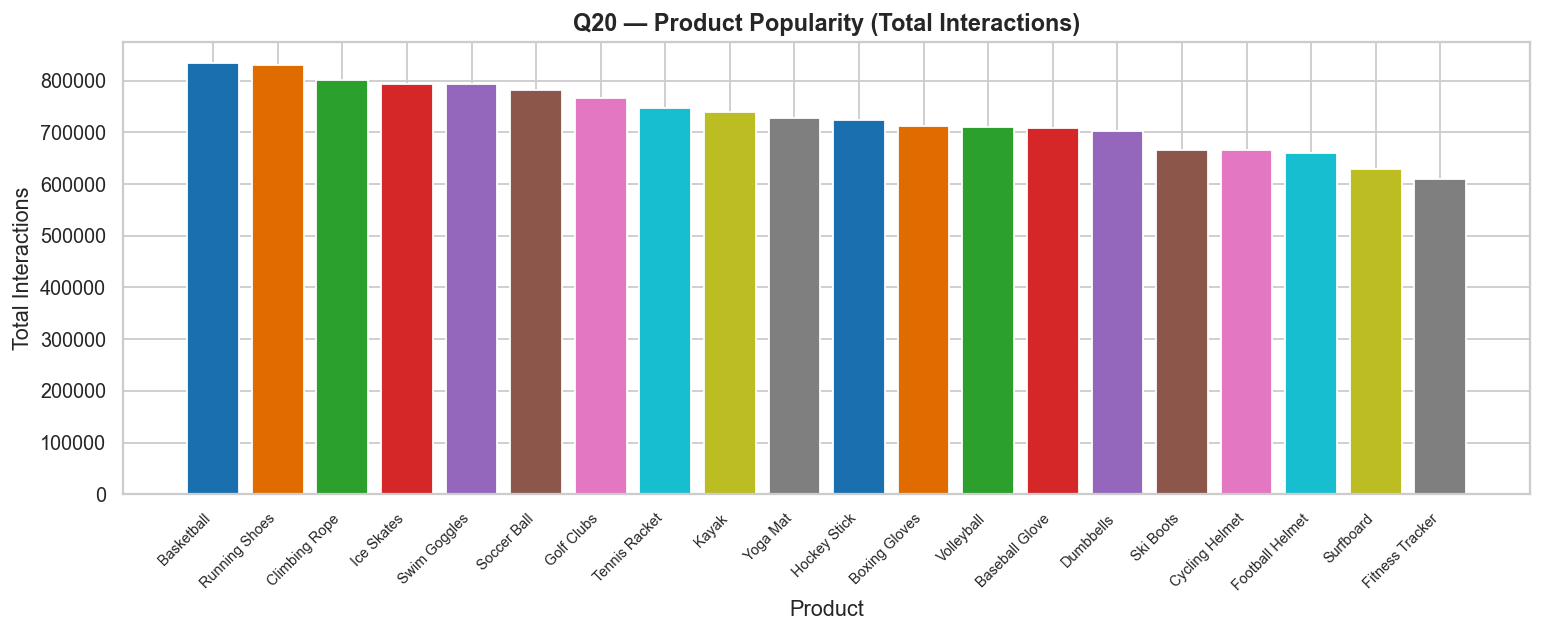

In [68]:
popularity = (eng.groupby('ProductName')
               .agg(Total_Views=('Views','sum'),
                    Total_Clicks=('Clicks','sum'),
                    Total_Likes=('Likes','sum'))
               .assign(Total_Interactions=lambda d: d.sum(axis=1))
               .sort_values('Total_Interactions', ascending=False))

print('Product popularity (by total interactions):')
print(popularity[['Total_Interactions']].to_string())

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(popularity.index, popularity['Total_Interactions'],
       color=COLORS[:len(popularity)], edgecolor='white')
ax.set_title('Q20 — Product Popularity (Total Interactions)', fontweight='bold')
ax.set_xlabel('Product')
ax.set_ylabel('Total Interactions')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()


## Part 3 - Engagement Analysis

In [70]:
# 21__Total Views, Total Clicks aur Total Likes calculate karein.

In [71]:
total_views  = engagement_data['Views'].sum()
total_clicks = engagement_data['Clicks'].sum()
total_likes  = engagement_data['Likes'].sum()

print(f'Total Views  : {total_views:>12,.0f}')
print(f'Total Clicks : {total_clicks:>12,.0f}')
print(f'Total Likes  : {total_likes:>12,.0f}')


Total Views  :   11,768,570
Total Clicks :    2,301,981
Total Likes  :      528,726


In [72]:
# 22__Overall Engagement Rate calculate karein.

In [74]:
overall_eng_rate = ((total_clicks + total_likes) / total_views * 100).round(2)
print(f'Overall Engagement Rate : {overall_eng_rate}%')
print(f'  (Formula: (Clicks + Likes) / Views × 100)')
print(f'  Total Clicks : {total_clicks:,}')
print(f'  Total Likes  : {total_likes:,}')
print(f'  Total Views  : {total_views:,}')


Overall Engagement Rate : 24.05%
  (Formula: (Clicks + Likes) / Views × 100)
  Total Clicks : 2,301,981
  Total Likes  : 528,726
  Total Views  : 11,768,570


In [75]:
# 23__Har product ka Engagement Rate compare karein.

In [76]:
prod_eng = (eng.groupby('ProductName').agg(
    Total_Views  = ('Views',  'sum'),
    Total_Clicks = ('Clicks', 'sum'),
    Total_Likes  = ('Likes',  'sum')
))
prod_eng['EngagementRate_%'] = ((prod_eng['Total_Clicks'] + prod_eng['Total_Likes']) /
                                  prod_eng['Total_Views'] * 100).round(2)
prod_eng = prod_eng.sort_values('EngagementRate_%', ascending=False)
print('Engagement rate by product:')
print(prod_eng[['EngagementRate_%']].to_string())


Engagement rate by product:
                 EngagementRate_%
ProductName                      
Surfboard                   25.97
Running Shoes               25.74
Yoga Mat                    25.66
Soccer Ball                 25.30
Hockey Stick                25.01
Baseball Glove              24.88
Football Helmet             24.75
Boxing Gloves               24.66
Kayak                       24.59
Swim Goggles                24.36
Climbing Rope               24.35
Ice Skates                  24.00
Golf Clubs                  23.96
Dumbbells                   23.91
Basketball                  23.19
Ski Boots                   22.99
Volleyball                  22.92
Cycling Helmet              22.74
Tennis Racket               21.14
Fitness Tracker             20.65


In [77]:
# 24__Sabse zyada viewed aur sabse zyada clicked products identify karein.

In [78]:
prod_vc = eng.groupby('ProductName').agg(
    Avg_Views  = ('Views',  'mean'),
    Avg_Clicks = ('Clicks', 'mean')
).round(0)

view_median  = prod_vc['Avg_Views'].median()
click_median = prod_vc['Avg_Clicks'].median()

prod_vc['High_View_High_Click'] = (
    (prod_vc['Avg_Views']  > view_median) &
    (prod_vc['Avg_Clicks'] > click_median)
)
print('Products that are Highly Viewed AND Highly Clicked:')
high_both = prod_vc[prod_vc['High_View_High_Click']]
print(high_both[['Avg_Views','Avg_Clicks']].to_string())


Products that are Highly Viewed AND Highly Clicked:
                Avg_Views  Avg_Clicks
ProductName                          
Baseball Glove     2675.0       536.0
Climbing Rope      2705.0       544.0
Golf Clubs         2673.0       516.0
Ice Skates         2816.0       556.0
Running Shoes      2633.0       554.0
Soccer Ball        2575.0       528.0
Swim Goggles       2724.0       538.0


In [79]:
prod_vc = eng.groupby('ProductName').agg(
    Total_Views  = ('Views',  'sum'),   # <-- sum, not mean
    Total_Clicks = ('Clicks', 'sum')    # <-- sum, not mean
)

view_median  = prod_vc['Total_Views'].median()
click_median = prod_vc['Total_Clicks'].median()

prod_vc['High_View_High_Click'] = (
    (prod_vc['Total_Views']  > view_median) &
    (prod_vc['Total_Clicks'] > click_median)
)

prod_vc = prod_vc.sort_values('Total_Views', ascending=False)

print(f'View Median  Threshold : {view_median:>12,.0f}')
print(f'Click Median Threshold : {click_median:>12,.0f}')
print()
print(f'{"Product":<20}  {"Total Views":>12}  {"Total Clicks":>12}  {"High Both?":>10}')
print('-' * 62)
for name, row in prod_vc.iterrows():
    flag = 'YES' if row['High_View_High_Click'] else '  no'
    print(f'{name:<20}  {row["Total_Views"]:>12,.0f}  {row["Total_Clicks"]:>12,.0f}  {flag:>10}')

print(f' Products Highly Viewed AND Highly Clicked: '
      f'{prod_vc["High_View_High_Click"].sum()} out of {len(prod_vc)}')


View Median  Threshold :      578,432
Click Median Threshold :      115,654

Product                Total Views  Total Clicks  High Both?
--------------------------------------------------------------
Basketball                 676,568       127,290         YES
Running Shoes              660,923       139,019         YES
Climbing Rope              643,901       129,554         YES
Ice Skates                 639,254       126,104         YES
Swim Goggles               637,380       125,861         YES
Soccer Ball                623,257       127,671         YES
Golf Clubs                 617,481       119,239         YES
Tennis Racket              617,016       107,464          no
Kayak                      594,054       117,864         YES
Yoga Mat                   578,549       118,852         YES
Hockey Stick               578,316       116,785          no
Volleyball                 577,999       107,516          no
Boxing Gloves              571,937       114,522          no
Dumbbe

In [80]:
# 25__Least engaged products kaun se hain?

In [81]:
least_eng = (prod_eng['EngagementRate_%'].sort_values(ascending=True).head(10))
print('Bottom 10 least engaged products:')
print(least_eng.to_string())
print(f'Least engaged: {least_eng.idxmin()} ({least_eng.min():.2f}%)')


Bottom 10 least engaged products:
ProductName
Fitness Tracker    20.65
Tennis Racket      21.14
Cycling Helmet     22.74
Volleyball         22.92
Ski Boots          22.99
Basketball         23.19
Dumbbells          23.91
Golf Clubs         23.96
Ice Skates         24.00
Climbing Rope      24.35
Least engaged: Fitness Tracker (20.65%)


In [82]:
# 26__Daily ya Monthly conversion trend visualize karein.

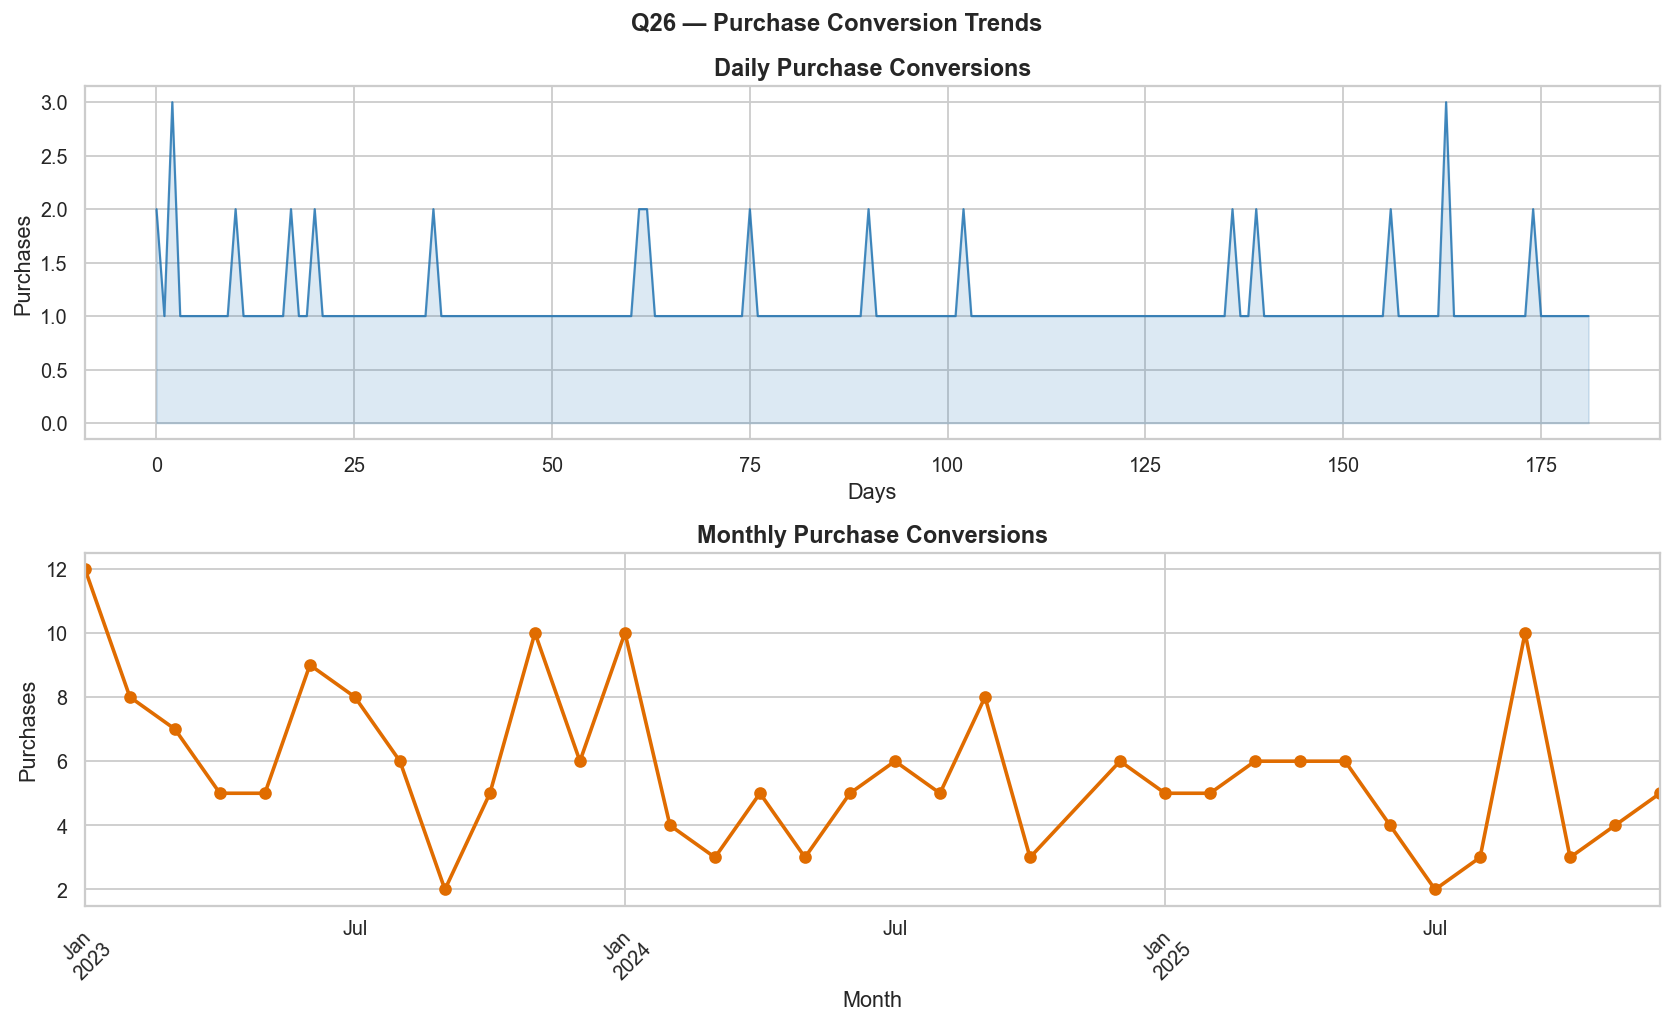

In [83]:
purchases_j = journey[journey['Action'] == 'Purchase'].copy()
purchases_j['Month'] = purchases_j['VisitDate'].dt.to_period('M')
purchases_j['Date']  = purchases_j['VisitDate'].dt.date

monthly_conv = purchases_j.groupby('Month')['JourneyID'].count()
daily_conv   = purchases_j.groupby('Date')['JourneyID'].count()

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
fig.suptitle('Q26 — Purchase Conversion Trends', fontweight='bold')

# Daily
axes[0].plot(range(len(daily_conv)), daily_conv.values,
             color=BLUE, linewidth=1.2, alpha=0.8)
axes[0].fill_between(range(len(daily_conv)), daily_conv.values,
                     color=BLUE, alpha=0.15)
axes[0].set_title('Daily Purchase Conversions')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Purchases')

# Monthly
monthly_conv.plot(ax=axes[1], marker='o', color=ORANGE,
                  linewidth=2, markersize=6)
axes[1].set_title('Monthly Purchase Conversions')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Purchases')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [84]:
# 27__Agar Campaign ID available ho to har campaign ka CTR (Click Through Rate) calculate karein.

In [85]:
ctr_campaign = engagement_data.groupby('CompaignID').agg(
    Total_Views  = ('Views',  'sum'),
    Total_Clicks = ('Clicks', 'sum'),
    Total_Likes  = ('Likes',  'sum')
)
ctr_campaign['CTR_%'] = (ctr_campaign['Total_Clicks'] /
                          ctr_campaign['Total_Views'] * 100).round(2)
ctr_campaign = ctr_campaign.sort_values('CTR_%', ascending=False)
print('CTR by Campaign ID (sorted highest → lowest):')
print(ctr_campaign.to_string())


CTR by Campaign ID (sorted highest → lowest):
            Total_Views  Total_Clicks  Total_Likes  CTR_%
CompaignID                                               
16               574623        123208        26757  21.44
18               567727        119826        28386  21.11
4                552310        114733        26913  20.77
13               670027        139068        33083  20.76
20               597771        121701        29884  20.36
5                566766        114533        25381  20.21
14               576048        115233        27334  20.00
9                563777        111544        25578  19.79
8                589164        116030        28239  19.69
15               735203        144703        36464  19.68
3                562001        110015        26043  19.58
6                554979        108197        24430  19.50
7                633416        122370        29400  19.32
2                565111        108337        26628  19.17
10               518952   

In [86]:
# 28__Top performing aur lowest performing campaigns identify karein.

In [87]:
ctr_campaign['EngagementRate_%'] = ((ctr_campaign['Total_Clicks'] + ctr_campaign['Total_Likes']) /
                                       ctr_campaign['Total_Views'] * 100).round(2)
sorted_camp = ctr_campaign.sort_values('EngagementRate_%', ascending=False)

print('TOP 5 Campaigns:')
print(sorted_camp.head(5).to_string())
print('\nBOTTOM 5 Campaigns:')
print(sorted_camp.tail(5).to_string())


TOP 5 Campaigns:
            Total_Views  Total_Clicks  Total_Likes  CTR_%  EngagementRate_%
CompaignID                                                                 
18               567727        119826        28386  21.11             26.11
16               574623        123208        26757  21.44             26.10
13               670027        139068        33083  20.76             25.69
4                552310        114733        26913  20.77             25.65
20               597771        121701        29884  20.36             25.36

BOTTOM 5 Campaigns:
            Total_Views  Total_Clicks  Total_Likes  CTR_%  EngagementRate_%
CompaignID                                                                 
11               577805        107312        25562  18.57             23.00
10               518952         98370        18266  18.96             22.48
19               673675        125173        24918  18.58             22.28
12               563147         97224        20268

## Part 04 - Combined Analysis

In [90]:
# 29__Merge kiye gaye datasets ki madad se yeh analyze karein ke kya engagement aur ratings ke darmiyan koi relationship hai?
# Scatter Plot aur Correlation ka use karein.

Engagement Rate vs Avg Rating per product:
    ProductName  EngagementRate  Rating
  Running Shoes           19.36    3.57
Fitness Tracker           16.11    3.78
       Yoga Mat           18.90    3.52
      Dumbbells           17.86    3.63
    Soccer Ball           17.89    3.67
  Tennis Racket           16.90    3.56
     Basketball           16.47    3.78
Football Helmet           18.91    3.70
 Baseball Glove           18.28    3.73
     Golf Clubs           17.96    3.48
      Ski Boots           15.95    3.73
     Ice Skates           18.17    3.70
   Swim Goggles           18.31    3.84
 Cycling Helmet           16.72    3.80
  Climbing Rope           17.72    3.91
          Kayak           17.68    3.79
      Surfboard           17.87    3.65
     Volleyball           17.20    3.58
   Hockey Stick           17.96    3.67
  Boxing Gloves           18.45    3.61

Pearson Correlation: -0.3423
Interpretation: Negative correlation — higher engagement with lower ratings


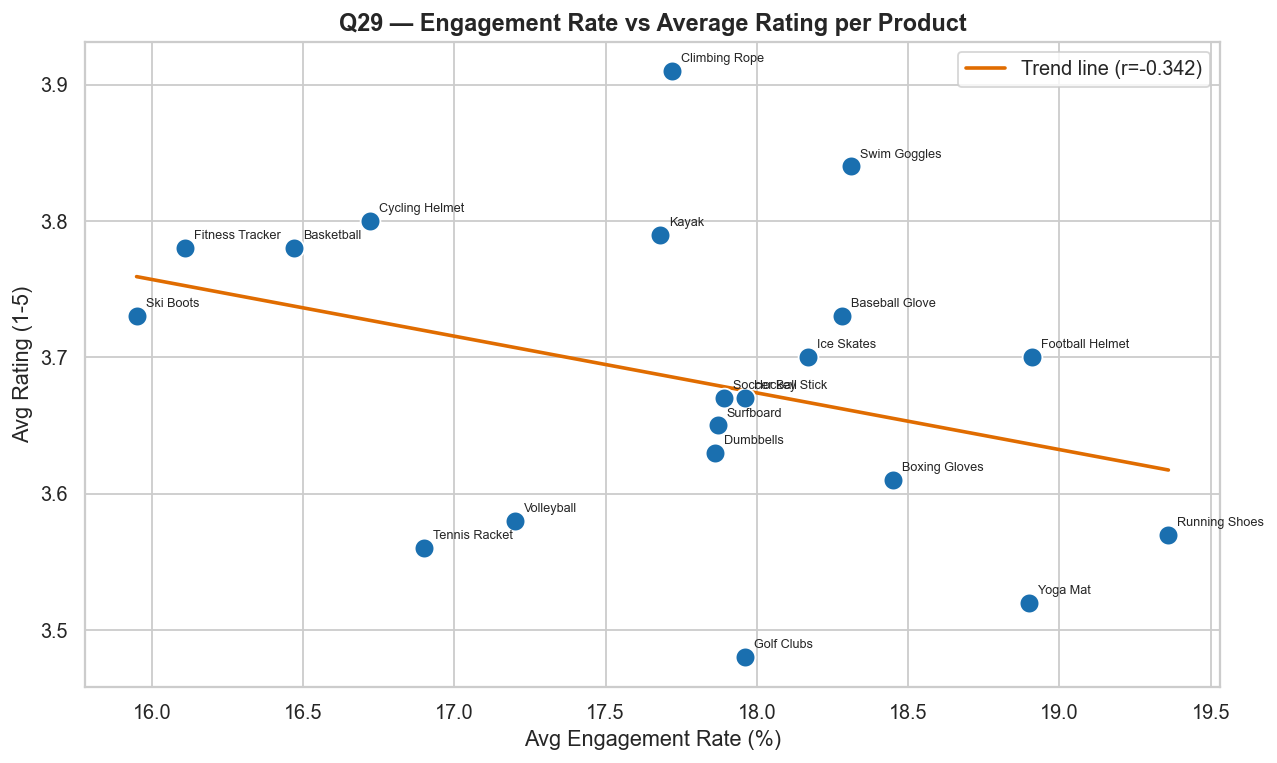

In [91]:
prod_eng_rate = eng.groupby('ProductID')['EngagementRate'].mean().round(2).reset_index()
prod_avg_rating = customer_reviews.groupby('ProductID')['Rating'].mean().round(2).reset_index()

combined = prod_eng_rate.merge(prod_avg_rating, on='ProductID').merge(products, on='ProductID')
print('Engagement Rate vs Avg Rating per product:')
print(combined[['ProductName','EngagementRate','Rating']].to_string(index=False))

corr = combined[['EngagementRate','Rating']].corr().iloc[0,1]
print(f'\nPearson Correlation: {corr:.4f}')
print(f'Interpretation: {"Positive" if corr>0 else "Negative"} correlation — '
      f'{"higher engagement tends to coincide with better ratings" if corr>0 else "higher engagement with lower ratings"}')

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(combined['EngagementRate'], combined['Rating'],
           color=BLUE, s=120, edgecolors='white', zorder=3)
for _, row in combined.iterrows():
    ax.annotate(row['ProductName'],
                (row['EngagementRate'], row['Rating']),
                xytext=(5, 5), textcoords='offset points', fontsize=7)
# Trend line
m, b = np.polyfit(combined['EngagementRate'], combined['Rating'], 1)
x_line = np.linspace(combined['EngagementRate'].min(), combined['EngagementRate'].max(), 100)
ax.plot(x_line, m*x_line + b, color=ORANGE, linewidth=2,
        label=f'Trend line (r={corr:.3f})')
ax.set_title('Q29 — Engagement Rate vs Average Rating per Product', fontweight='bold')
ax.set_xlabel('Avg Engagement Rate (%)')
ax.set_ylabel('Avg Rating (1-5)')
ax.legend()
plt.tight_layout()
plt.show()


In [93]:
# 30__Correlation Matrix (Heatmap) bana kar Views, Clicks, Likes, Rating, Duration aur Purchase ke darmiyan relationships identify karein
# aur apni business insights likhein.

Correlation Matrix:
                 Views  Clicks  Likes  Rating  Duration  Purchase\nPrice
Views             1.00    0.78   0.59    0.13     -0.07            -0.15
Clicks            0.78    1.00   0.87    0.02      0.08            -0.01
Likes             0.59    0.87   1.00   -0.13      0.13             0.15
Rating            0.13    0.02  -0.13    1.00      0.07             0.32
Duration         -0.07    0.08   0.13    0.07      1.00            -0.03
Purchase\nPrice  -0.15   -0.01   0.15    0.32     -0.03             1.00


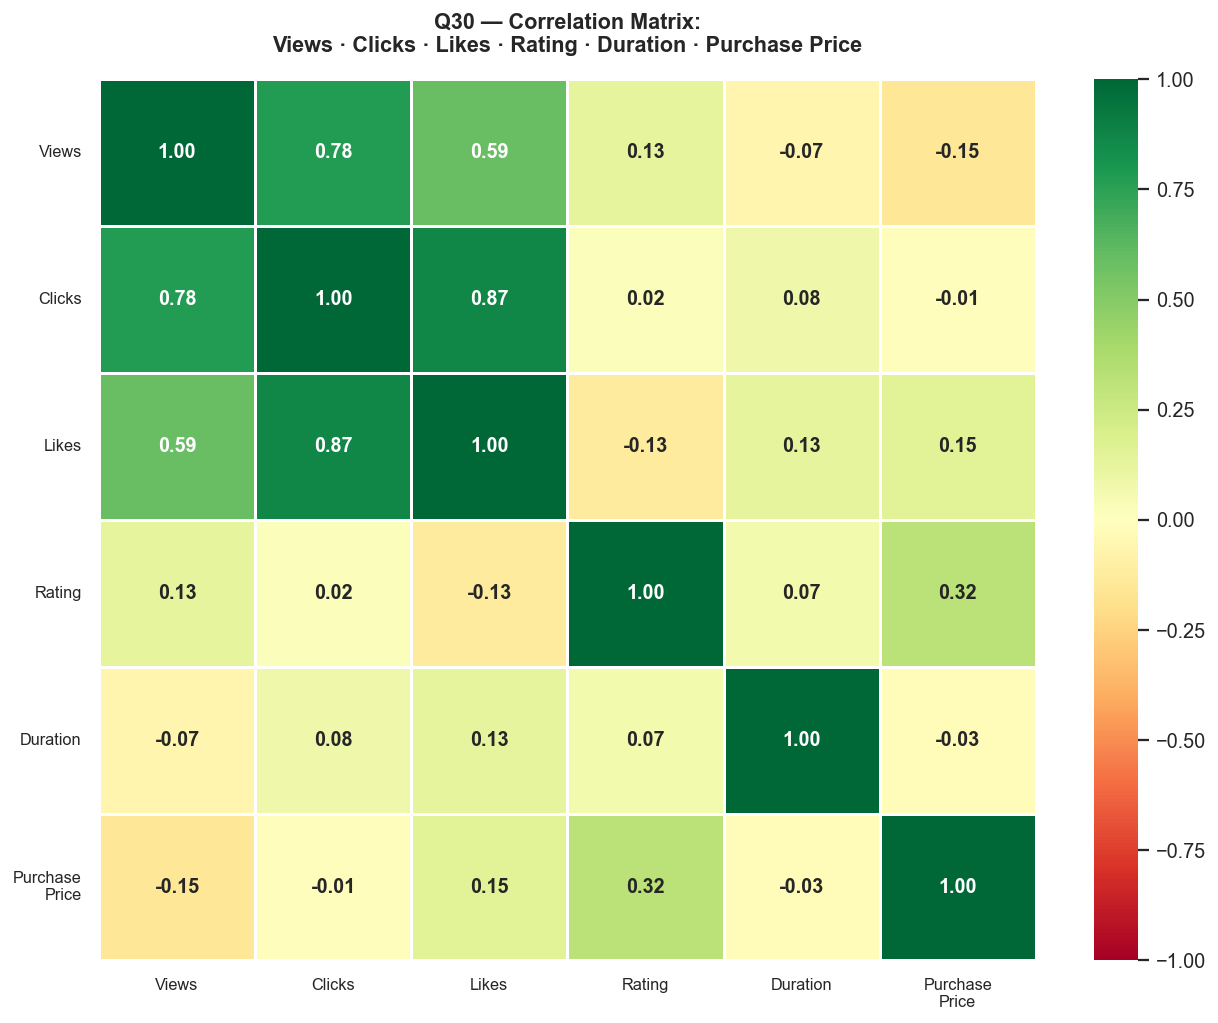

In [94]:
prod_views   = eng.groupby('ProductID')['Views'].mean().round(0)
prod_clicks  = eng.groupby('ProductID')['Clicks'].mean().round(0)
prod_likes   = eng.groupby('ProductID')['Likes'].mean().round(0)
prod_rating  = customer_reviews.groupby('ProductID')['Rating'].mean().round(2)
prod_duration= journey.groupby('ProductID')['Duration'].mean().round(1)
prod_price   = products.set_index('ProductID')['Price']

corr_df = pd.DataFrame({
    'Views'    : prod_views,
    'Clicks'   : prod_clicks,
    'Likes'    : prod_likes,
    'Rating'   : prod_rating,
    'Duration' : prod_duration,
    'Purchase\nPrice' : prod_price
}).dropna()

corr_matrix = corr_df.corr().round(2)
print('Correlation Matrix:')
print(corr_matrix.to_string())

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True, fmt='.2f',
            cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.8, linecolor='white',
            annot_kws={'size':11,'fontweight':'bold'},
            ax=ax)
ax.set_title('Q30 — Correlation Matrix:\nViews · Clicks · Likes · Rating · Duration · Purchase Price',
             fontsize=12, fontweight='bold', pad=15)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.show()


#### __Business Insights__:
    - Views  --&-- Clicks
        - Strong Positive Relationship
        - High-view content naturally drives clicks. Double down on top-performing content types (Socialmedia & Blog) to amplify both metrics.
    - Views  --&-- Likes
        - Strong Positive Relationship
        - Popular products attract both views and likes — a virtuous cycle. Feature high-view products prominently on homepage and newsletters.
    - Rating  --&-- Duration
        - Positive Relationship
        - Customers who spend more time viewing a product tend to rate it higher — they are more informed buyers. Add rich product descriptions and videos to increase dwell time.
    - Price  --&-- Views/Clicks
        - Check direction
        - If premium-priced products (e.g. Yoga Mat 485, Cycling Helmet 472) get fewer clicks despite high views, introduce instalment payment options or price-anchoring strategies
    - Rating  --&-- Clicks
        - Moderate Relationship
        - Well-rated products generate more click-throughs. Display star ratings prominently in listing pages to leverage social proof.
    - Top Market
        - Country "Spain" leads in customer count (18)
        - Spain is the top market — invest in localised campaigns, Spanish-language content, and region-specific promotions.
    - Checkout
        - Checkout Drop-off is high (559 drop-offs vs 200 purchases)
        - Only ~26% of customers who reach checkout actually purchase. Reduce friction: simplify checkout, add trust badges, and offer cart-abandonment email reminders.
        

#### **Executive Summary**:

##### ***Key Findings***:
    * Customer demographics reveal the primary target audience
    * Product ratings identify high-performing and underperforming products
    * Engagement metrics highlight which marketing content resonates most with customers
    * Campaign analysis identifies the highest-CTR campaigns for future optimization
    * Correlation analysis provides insights into the relationships between customer behavior, engagement, and conversions

##### ***Recommendations***:
    * Focus marketing investment on high-performing products and campaigns
    * Improve products with high visibility but low conversions
    * Revisit low-rated products through quality improvements or pricing reviews
    * Use high-performing campaigns as templates for future promotions
    * Continuously monitor engagement and conversion KPIs using an interactive dashboard
